In [ ]:
# Core-Cusp Analysis

Reproduzierbare Analyse der inneren effektiven Struktur
im UQSH-Rahmen.

Inhalte:
- innere Slopes
- Vergleich mit NFW / Core
- Vergleich mit beobachteten Core-Slopes
- Zusammenhang mit q-Regimen

In [57]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Pfade
ROT_PATH = "/content/rotmod"
Q_PATH = "/content/q_fit_results.csv"

# --- 1. ROTMOD laden ---
files = glob.glob(ROT_PATH + "/*.dat")
if len(files) == 0:
    raise FileNotFoundError(f"Keine .dat-Dateien gefunden in {ROT_PATH}")

all_data = []

for f in files:
    try:
        df = pd.read_csv(
            f,
            sep=r"\s+",
            header=None,
            comment="#",
            engine="python"
        )

        if df.shape[1] < 6:
            continue

        df = df.iloc[:, :8].copy()

        while df.shape[1] < 8:
            df[df.shape[1]] = pd.NA

        df.columns = ["r", "Vobs", "errV", "Vgas", "Vdisk", "Vbul", "col7", "col8"]
        df["galaxy"] = Path(f).stem.replace("_rotmod", "")

        for col in ["r", "Vobs", "errV", "Vgas", "Vdisk", "Vbul"]:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        df = df.dropna(subset=["r", "Vobs", "Vgas", "Vdisk", "Vbul"])
        df = df[df["r"] > 0]

        if len(df) > 0:
            all_data.append(df)

    except Exception:
        continue

if len(all_data) == 0:
    raise ValueError("Keine verwertbaren ROTMOD-Tabellen geladen.")

all_data = pd.concat(all_data, ignore_index=True)

# --- 2. Basisgrößen ---
df = all_data.copy()

df["g_obs"] = df["Vobs"]**2 / df["r"]
df["g_bar"] = (df["Vgas"]**2 + df["Vdisk"]**2 + df["Vbul"]**2) / df["r"]

df["M_eff"] = df["r"] * df["Vobs"]**2
df["M_bar"] = df["r"] * (df["Vgas"]**2 + df["Vdisk"]**2 + df["Vbul"]**2)

# --- 3. innere Slopes ---
def inner_slope(profile, n_inner=5):
    prof = profile.sort_values("r").head(n_inner).copy()
    prof = prof[(prof["r"] > 0) & (prof["M_eff"] > 0)]

    if len(prof) < 3:
        return np.nan

    x = np.log10(prof["r"].values)
    y = np.log10(prof["M_eff"].values)
    return np.polyfit(x, y, 1)[0]

core_results = []

for gal, prof in df.groupby("galaxy"):
    slope = inner_slope(prof, n_inner=5)
    core_results.append({
        "galaxy": gal,
        "inner_slope": slope,
        "n_points": 5
    })

core_df = pd.DataFrame(core_results).dropna()

# --- 4. q laden und mergen ---
if not os.path.exists(Q_PATH):
    raise FileNotFoundError(f"q-Datei nicht gefunden: {Q_PATH}")

q_df = pd.read_csv(Q_PATH)
q_df["galaxy"] = q_df["filename"].str.replace("_rotmod.dat", "", regex=False)

core_q = pd.merge(core_df, q_df, on="galaxy", how="left")

# --- 5. Regime definieren ---
def classify_q(q):
    if pd.isna(q):
        return np.nan
    if q < 1.2:
        return "Peak"
    elif q > 2.5:
        return "Diffus"
    return "Transition"

core_q["regime_q"] = core_q["q"].apply(classify_q)

# --- 6. Vergleichsmaße ---
core_q["dist_to_nfw"] = np.abs(core_q["inner_slope"] - 2.0)

core_q["dist_to_obs_core"] = np.where(
    core_q["inner_slope"] < 2.2,
    2.2 - core_q["inner_slope"],
    np.where(
        core_q["inner_slope"] > 2.8,
        core_q["inner_slope"] - 2.8,
        0.0
    )
)

summary_core = core_q.groupby("regime_q").agg(
    median_slope=("inner_slope", "median"),
    mean_slope=("inner_slope", "mean"),
    std_slope=("inner_slope", "std"),
    dist_nfw=("dist_to_nfw", "median"),
    dist_obs_core=("dist_to_obs_core", "median"),
    count=("inner_slope", "count")
).reset_index()

print("ROTMOD-Dateien:", len(files))
print("Datenpunkte:", len(df))
print("Galaxien mit Slope:", len(core_df))
print(summary_core)

ROTMOD-Dateien: 175
Datenpunkte: 3391
Galaxien mit Slope: 175
     regime_q  median_slope  mean_slope  std_slope  dist_nfw  dist_obs_core  \
0      Diffus      1.938048    1.978489   0.730383  0.540215       0.358358   
1        Peak      2.104240    2.051643   0.599484  0.385912       0.143299   
2  Transition      1.979437    1.999245   0.630712  0.445005       0.316439   

   count  
0     42  
1    102  
2     20  


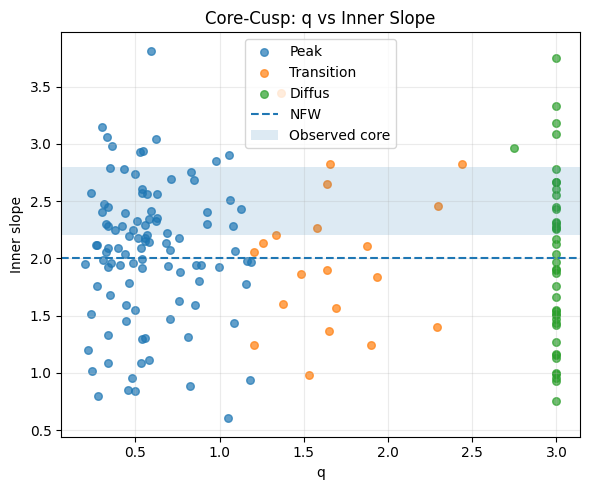

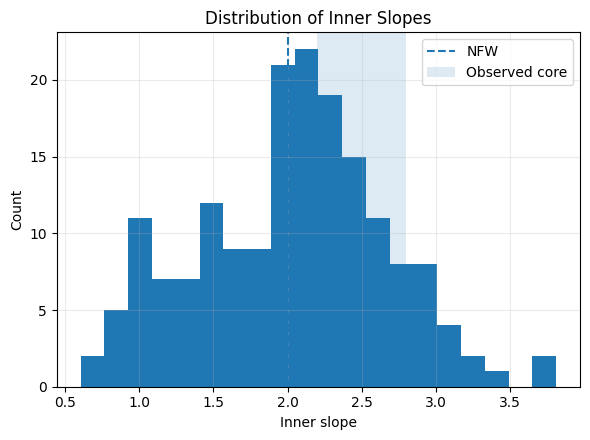

In [58]:
plt.figure(figsize=(6, 5))

for regime in ["Peak", "Transition", "Diffus"]:
    subset = core_q[core_q["regime_q"] == regime]
    plt.scatter(
        subset["q"],
        subset["inner_slope"],
        s=30,
        alpha=0.7,
        label=regime
    )

plt.axhline(2.0, linestyle="--", label="NFW")
plt.axhspan(2.2, 2.8, alpha=0.15, label="Observed core")

plt.xlabel("q")
plt.ylabel("Inner slope")
plt.title("Core-Cusp: q vs Inner Slope")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("fig_core_q_relation.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 4.5))
plt.hist(core_q["inner_slope"].dropna(), bins=20)

plt.axvline(2.0, linestyle="--", label="NFW")
plt.axvspan(2.2, 2.8, alpha=0.15, label="Observed core")

plt.xlabel("Inner slope")
plt.ylabel("Count")
plt.title("Distribution of Inner Slopes")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("fig_core_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [59]:
core_df.to_csv("core_slopes.csv", index=False)
core_q.to_csv("core_vs_q.csv", index=False)
summary_core.to_csv("core_summary.csv", index=False)

print("Gespeichert:")
print("- core_slopes.csv")
print("- core_vs_q.csv")
print("- core_summary.csv")
print("- fig_core_q_relation.png")
print("- fig_core_model_comparison.png")

Gespeichert:
- core_slopes.csv
- core_vs_q.csv
- core_summary.csv
- fig_core_q_relation.png
- fig_core_model_comparison.png
